# CH 5 - 5 : TEST CONCLUSIONS AND ERRORS

## Version clarifiée

Ce notebook explique les **conclusions possibles d'un test d'hypothèse**, les **erreurs de Type I et Type II**, puis ajoute une section spéciale pour clarifier les questions suivantes :

- C'est quoi le **seuil critique** ?
- C'est quoi l'**erreur Type II** ?
- C'est quoi la **puissance statistique** ?
- Faut-il calculer Type I et Type II à chaque fois ?
- À partir de quel seuil la puissance devient acceptable ?

L'objectif est de faire le lien avec le trading EBTA :

> Un test statistique ne donne jamais une certitude absolue.  
> Il sert à gérer le risque de se tromper quand on décide si une stratégie mérite du capital.


## 1. Le décor : $H_0$ et la décision du test

Dans un test d'hypothèse appliqué à une stratégie de trading, on part généralement de :

$$
H_0 : \text{la stratégie n'a aucun edge réel}
$$

Cela veut dire :

> Par défaut, je suppose que la règle est nulle, jusqu'à preuve statistique du contraire.

Le test peut ensuite prendre deux décisions :

1. **Rejeter $H_0$**  
   → les preuves sont assez fortes pour dire que la stratégie semble avoir un edge.

2. **Ne pas rejeter $H_0$**  
   → les preuves ne sont pas assez fortes pour valider l'edge.

Point important :

> Ne pas rejeter $H_0$ ne veut pas dire que la stratégie est forcément nulle.  
> Cela veut seulement dire : “je n'ai pas assez de preuves.”


## 2. Les quatre issues possibles

Un test statistique compare deux choses :

- la **réalité**, que tu ne connais pas ;
- la **décision du test**, basée sur ton backtest.

| Réalité | Décision du test | Résultat |
|---|---|---|
| La règle est vraiment nulle | On retient $H_0$ | Décision correcte |
| La règle est vraiment nulle | On rejette $H_0$ | Erreur Type I |
| La règle a vraiment un edge | On rejette $H_0$ | Décision correcte |
| La règle a vraiment un edge | On retient $H_0$ | Erreur Type II |

En version trading :

- **Type I** = croire à une illusion.
- **Type II** = rater une vraie opportunité.


## 3. Erreur Type I : valider une stratégie nulle

L'erreur Type I arrive quand :

1. La stratégie est réellement nulle.
2. Mais ton backtest semble très bon par hasard.
3. Le test rejette $H_0$.
4. Tu crois avoir trouvé un edge.

En trading :

> Type I = prendre de la chance pour du talent.

C'est l'erreur la plus dangereuse pour le capital, parce qu'elle peut te faire trader une règle sans espérance positive réelle.


## 4. Erreur Type II : rater un vrai edge

L'erreur Type II arrive quand :

1. La stratégie a réellement un edge.
2. Mais le backtest n'est pas assez convaincant.
3. Le test ne rejette pas $H_0$.
4. Tu ignores ou abandonnes une règle qui avait pourtant du potentiel.

En trading :

> Type II = un vrai edge passe sous le radar.

C'est une opportunité manquée.  
Ce n'est généralement pas aussi grave qu'une erreur Type I, car tu ne mets pas directement ton capital en danger.


# Section déclic : comprendre Type II et puissance à petit pas

## A. L'image du radar

Imagine que tu as un radar.

Le radar cherche à détecter un avion.

Dans notre cas :

- **l'avion** = un vrai edge ;
- **le radar** = ton test statistique ;
- **le bruit dans le ciel** = la variance des résultats ;
- **le signal radar** = la performance du backtest.

Si l'avion est là mais que ton radar ne le voit pas, tu fais une erreur Type II.

Donc :

> **Erreur Type II = le vrai edge existe, mais ton test ne le détecte pas.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(123)

# Paramètres pédagogiques
n_simulations = 20_000
n_trades = 50
sigma = 1.0
true_edge = 0.10
alpha = 0.05

# Test unilatéral à droite
z_alpha = 1.645
standard_error = sigma / np.sqrt(n_trades)
critical_value = z_alpha * standard_error

# Ici, on simule un monde où la stratégie a vraiment un edge.
samples_with_edge = np.random.normal(true_edge, sigma, size=(n_simulations, n_trades))
observed_means = samples_with_edge.mean(axis=1)

detected_edge = observed_means > critical_value
missed_edge = observed_means <= critical_value

power = detected_edge.mean()
type_2 = missed_edge.mean()

print(f"Nombre de trades : {n_trades}")
print(f"Vrai edge simulé : {true_edge:.2f}R par trade")
print(f"Seuil critique : {critical_value:.3f}R")
print(f"Puissance statistique : {power:.2%}")
print(f"Erreur Type II : {type_2:.2%}")

Nombre de trades : 50
Vrai edge simulé : 0.10R par trade
Seuil critique : 0.233R
Puissance statistique : 17.53%
Erreur Type II : 82.47%


## B. Lecture du résultat

Dans la simulation précédente, la stratégie a vraiment un edge de :

$$
+0,10R \text{ par trade}
$$

Mais elle n'est testée que sur **50 trades**.

Même avec un vrai edge, tous les backtests ne dépassent pas le seuil critique.

Donc certains backtests donnent une conclusion du type :

> “Je n'ai pas assez de preuves.”

Alors que la stratégie avait réellement un edge.

C'est ça le déclic :

> **Une stratégie peut être bonne, mais ton test peut être trop faible pour le voir.**


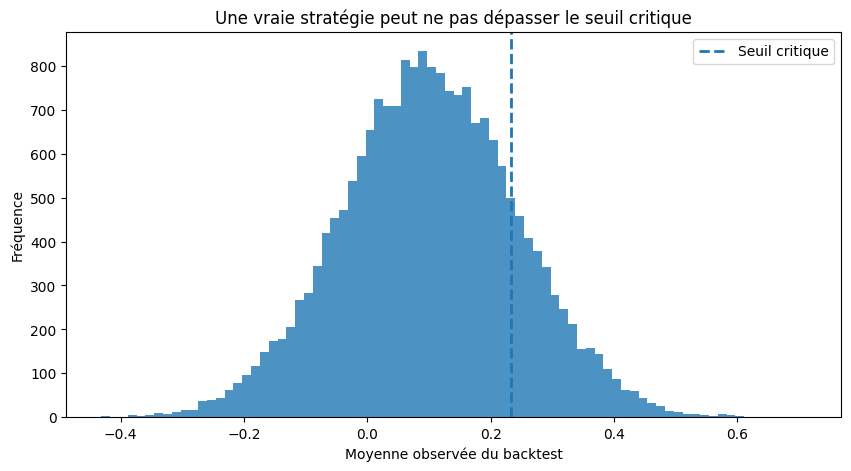

In [2]:
plt.figure(figsize=(10, 5))
plt.hist(observed_means, bins=80, alpha=0.8)
plt.axvline(critical_value, linestyle="--", linewidth=2, label="Seuil critique")
plt.title("Une vraie stratégie peut ne pas dépasser le seuil critique")
plt.xlabel("Moyenne observée du backtest")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## C. C'est quoi la puissance statistique ?

La puissance statistique répond à cette question :

> Si la stratégie a vraiment un edge, quelle est la probabilité que mon test le détecte ?

Donc :

$$
\text{Puissance} = 1 - \text{Erreur Type II}
$$

En mots simples :

- **Erreur Type II** = rater un vrai edge ;
- **Puissance** = réussir à détecter un vrai edge.

Exemple :

Si la puissance est de 80 %, cela veut dire :

> Si l'edge existe vraiment, le test a 80 % de chances de le détecter.

Donc l'erreur Type II est :

$$
1 - 80\% = 20\%
$$

Autrement dit :

> Même si l'edge existe vraiment, tu as encore 20 % de risque de le rater.


## D. C'est quoi le seuil critique ?

Le seuil critique est la frontière à dépasser pour rejeter $H_0$.

Dans ce notebook, on a utilisé :

$$
\text{seuil critique} = 1,645 \times \text{erreur standard}
$$

Pourquoi 1,645 ?

Parce qu'on fait un test unilatéral à droite avec :

$$
\alpha = 5\%
$$

Cela veut dire :

> Je veux que seulement environ 5 % des stratégies vraiment nulles puissent dépasser ce seuil par hasard.

Donc le seuil critique sert à protéger contre l'erreur Type I.

En trading :

> Le seuil critique est la barrière anti-illusion.


In [3]:
# Simulation sous H0 : stratégie sans aucun edge
np.random.seed(456)

samples_null = np.random.normal(0.0, sigma, size=(n_simulations, n_trades))
means_null = samples_null.mean(axis=1)

false_positives = means_null > critical_value
type_1 = false_positives.mean()

print(f"Alpha choisi : {alpha:.2%}")
print(f"Erreur Type I empirique simulée : {type_1:.2%}")

Alpha choisi : 5.00%
Erreur Type I empirique simulée : 4.88%


## E. Faut-il calculer Type I et Type II à chaque fois ?

### Pour Type I

Pas vraiment.

Tu contrôles Type I avec le seuil alpha.

Si tu choisis :

$$
\alpha = 5\%
$$

tu dis :

> J'accepte environ 5 % de risque de valider une stratégie nulle par erreur.

Donc :

$$
\text{Type I} \approx \alpha
$$

Tu ne le recalcules pas forcément à chaque fois.  
Tu le fixes à l'avance avec ton seuil de p-value.

### Pour Type II

C'est plus subtil.

Tu ne connais pas directement Type II, parce qu'il dépend du vrai edge de la stratégie, et ce vrai edge est inconnu.

Donc tu ne peux pas toujours dire :

> Mon erreur Type II exacte est de 17,3 %.

Mais tu peux estimer la puissance pour une taille d'edge réaliste.

Par exemple :

> Est-ce que mon test a assez de puissance pour détecter un edge de +0,10R par trade ?


## F. À partir de quel seuil la puissance est acceptable ?

Le repère classique est :

$$
80\%
$$

Donc :

| Puissance | Interprétation |
|---|---|
| < 50 % | Radar faible |
| 50 % à 70 % | Test fragile |
| 70 % à 80 % | Correct mais pas idéal |
| ≥ 80 % | Acceptable |
| ≥ 90 % | Très confortable |

Mais attention :

> La puissance doit toujours être liée à une taille d'edge.

On ne dit pas seulement :

> “Mon test a 80 % de puissance.”

On dit :

> “Mon test a 80 % de puissance pour détecter un edge de +0,10R par trade avec 300 trades.”


In [4]:
# Comparons la puissance selon le nombre de trades
np.random.seed(789)

sample_sizes = [25, 50, 100, 200, 300, 500, 1000]
edge_to_detect = 0.10
rows = []

for n in sample_sizes:
    se = sigma / np.sqrt(n)
    cv = z_alpha * se

    samples = np.random.normal(edge_to_detect, sigma, size=(n_simulations, n))
    means = samples.mean(axis=1)

    pwr = (means > cv).mean()
    type_2_rate = 1 - pwr

    rows.append({
        "Nombre de trades": n,
        "Edge à détecter": edge_to_detect,
        "Seuil critique": cv,
        "Puissance": pwr,
        "Erreur Type II": type_2_rate
    })

power_table = pd.DataFrame(rows)
power_table

,Nombre de trades,Edge à détecter,Seuil critique,Puissance,Erreur Type II
0,25,0.1,0.329000,0.12915,0.87085
1,50,0.1,0.232638,0.17170,0.82830
2,100,0.1,0.164500,0.25705,0.74295
3,200,0.1,0.116319,0.40975,0.59025
4,300,0.1,0.094974,0.52885,0.47115
5,500,0.1,0.073567,0.72255,0.27745
6,1000,0.1,0.052019,0.93345,0.06655


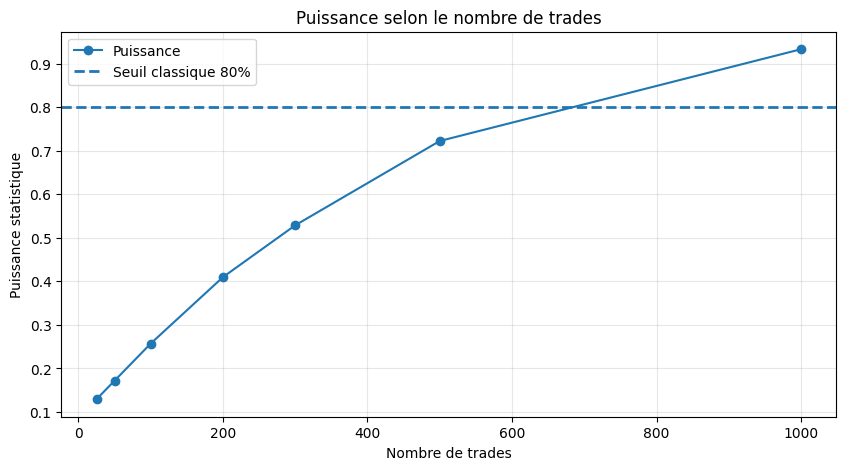

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(power_table["Nombre de trades"], power_table["Puissance"], marker="o", label="Puissance")
plt.axhline(0.80, linestyle="--", linewidth=2, label="Seuil classique 80%")
plt.title("Puissance selon le nombre de trades")
plt.xlabel("Nombre de trades")
plt.ylabel("Puissance statistique")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## G. Le vrai EUREKA

Quand un test échoue, ton cerveau ne doit pas dire automatiquement :

> “La stratégie est nulle.”

Il doit dire :

> “Je n'ai pas assez de preuves. Maintenant, est-ce que mon test avait assez de puissance ?”

C'est le changement mental important.

### Si la puissance est faible

Un échec du test ne veut pas dire grand-chose.

Ton radar était trop faible.

### Si la puissance est élevée

Un échec du test devient beaucoup plus informatif.

Si ton test avait 85 % ou 90 % de puissance pour détecter un edge réaliste, mais qu'il ne détecte rien, alors tu peux devenir plus sceptique.

Phrase finale :

> **Alpha protège contre les fausses bonnes stratégies.  
> La puissance protège contre le fait de jeter trop vite les vraies bonnes stratégies.**


# Résumé final

## Type I

> Je valide une stratégie nulle.

En trading :

> Je mets du capital sur une illusion.

C'est contrôlé par :

$$
\alpha
$$

## Type II

> Je rate une stratégie qui avait réellement un edge.

En trading :

> Je laisse passer une opportunité.

C'est lié à :

$$
\text{Puissance} = 1 - \text{Type II}
$$

## Seuil critique

> La barrière que le backtest doit franchir pour rejeter $H_0$.

Il protège contre les faux positifs.

## Puissance statistique

> La capacité du test à détecter un vrai edge quand il existe.

Repère classique :

$$
80\%
$$

## Phrase EBTA

> Je ne cherche pas à sauver une stratégie ambiguë.  
> Je cherche à protéger mon capital tout en gardant assez de puissance pour ne pas jeter trop vite un vrai edge.
